<a href="https://colab.research.google.com/github/geethi02/Data-Analysis-Project/blob/main/Early_Blight_and_Late_Blight_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import kagglehub


print("Downloading the dataset from KaggleHub...")

download_path = kagglehub.dataset_download("aarishasifkhan/plantvillage-potato-disease-dataset")
print(f"✅ Dataset downloaded to: {download_path}\n")


dataset_dir = os.path.join(download_path, 'PlantVillage')
class_dirs = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

# Print overview information
print("Inspecting dataset contents...")
print("============================")

try:
    # Loop through each class directory to count images
    for class_dir in class_dirs:
        class_path = os.path.join(dataset_dir, class_dir)
        num_images = len(os.listdir(class_path))
        print(f"Class: {class_dir}, Number of Images: {num_images}")

    # Calculate the total number of images
    total_images = sum(len(os.listdir(os.path.join(dataset_dir, class_dir))) for class_dir in class_dirs)
    print(f"\nTotal Number of Images in Dataset: {total_images}")

except FileNotFoundError:
    print(f"❌ Error: The directory '{dataset_dir}' was not found.")
    print("Please check if the downloaded dataset has the expected 'PlantVillage' sub-folder.")

100%|██████████| 37.8M/37.8M [00:00<00:00, 209MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/aarishasifkhan/plantvillage-potato-disease-dataset/versions/1

Inspecting dataset contents...
Class: Potato___Early_blight, Number of Images: 1000
Class: Potato___Late_blight, Number of Images: 1000
Class: Potato___healthy, Number of Images: 152

Total Number of Images in Dataset: 2152


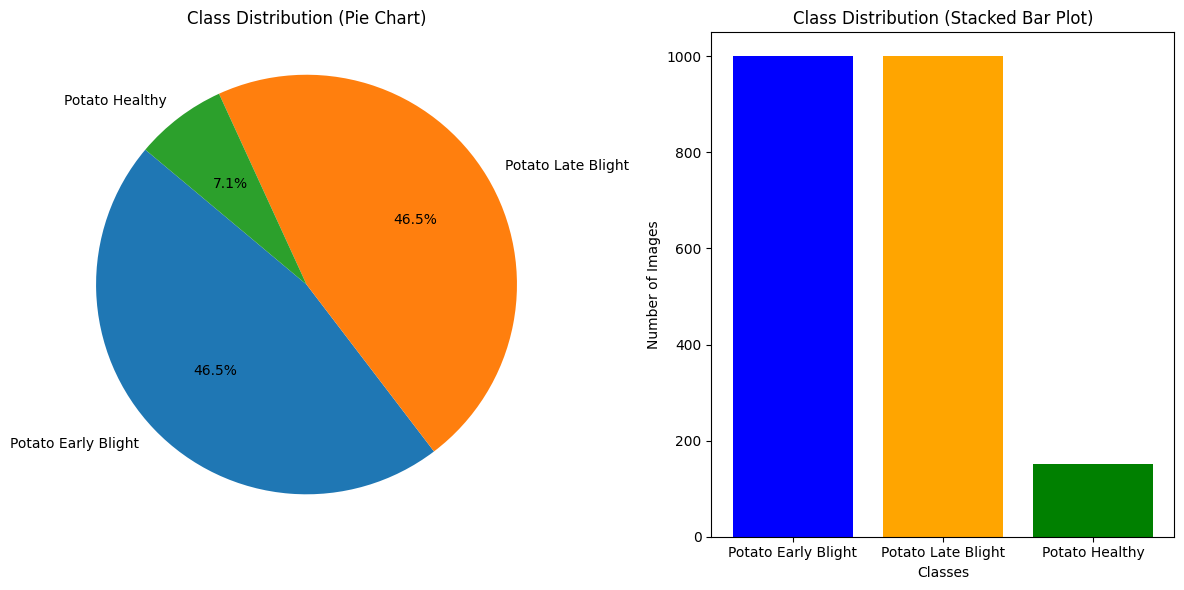

In [ ]:
# Define the path to the dataset and the class folders
dataset_dir = os.path.join(download_path, 'PlantVillage')
class_dirs = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
class_labels = ['Potato Early Blight', 'Potato Late Blight', 'Potato Healthy']

# Calculate number of images in each class
class_counts = []
for class_dir in class_dirs:
    class_path = os.path.join(dataset_dir, class_dir)
    num_images = len(os.listdir(class_path))
    class_counts.append(num_images)

# Calculate percentages for pie chart
total_images = sum(class_counts)
percentages = [(count / total_images) * 100 for count in class_counts]

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart
ax1.pie(percentages, labels=class_labels, autopct='%1.1f%%', startangle=140)
ax1.set_title('Class Distribution (Pie Chart)')
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Stacked bar plot
ax2.bar(class_labels, class_counts, color=['blue', 'orange', 'green'])
ax2.set_title('Class Distribution (Stacked Bar Plot)')
ax2.set_xlabel('Classes')
ax2.set_ylabel('Number of Images')

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

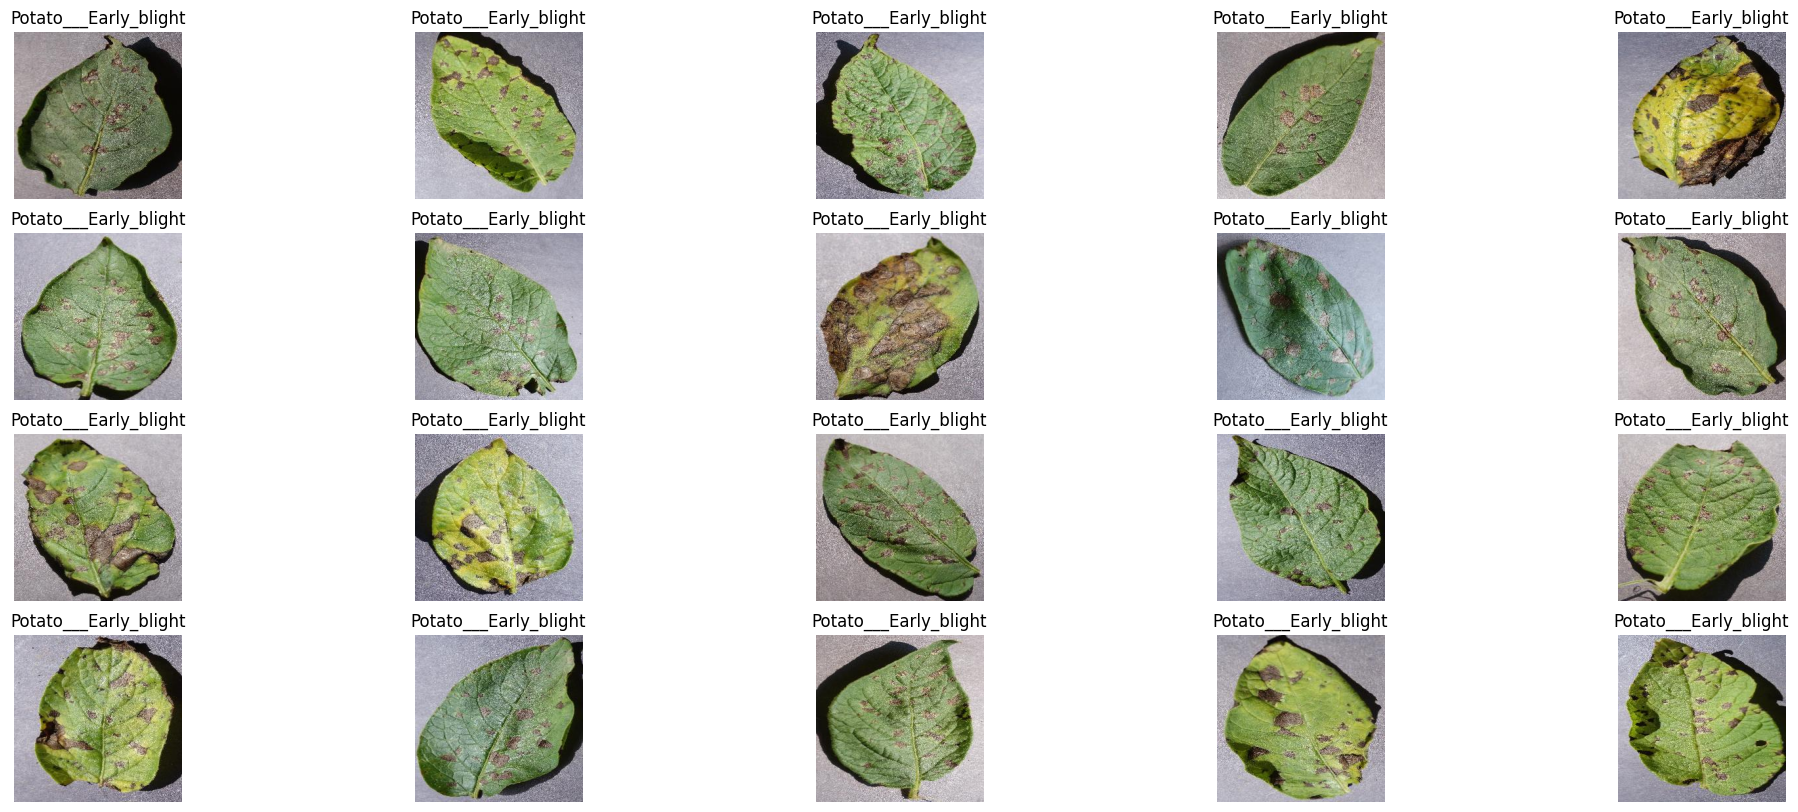

In [ ]:
# Define the path to the dataset and the class folder
dataset_dir = os.path.join(download_path, 'PlantVillage')
class_dir = 'Potato___Early_blight'
class_path = os.path.join(dataset_dir, class_dir)

# Get the first 20 image filenames
image_files = os.listdir(class_path)[:20]

# Plot the images
plt.figure(figsize=(25, 10))  # Adjusted figsize to accommodate 20 images
for i, image_file in enumerate(image_files):
    img_path = os.path.join(class_path, image_file)
    img = Image.open(img_path)
    plt.subplot(4, 5, i + 1)  # Adjusted subplot layout to 4 rows and 5 columns
    plt.imshow(img)
    plt.title(class_dir)
    plt.axis('off')
plt.show()


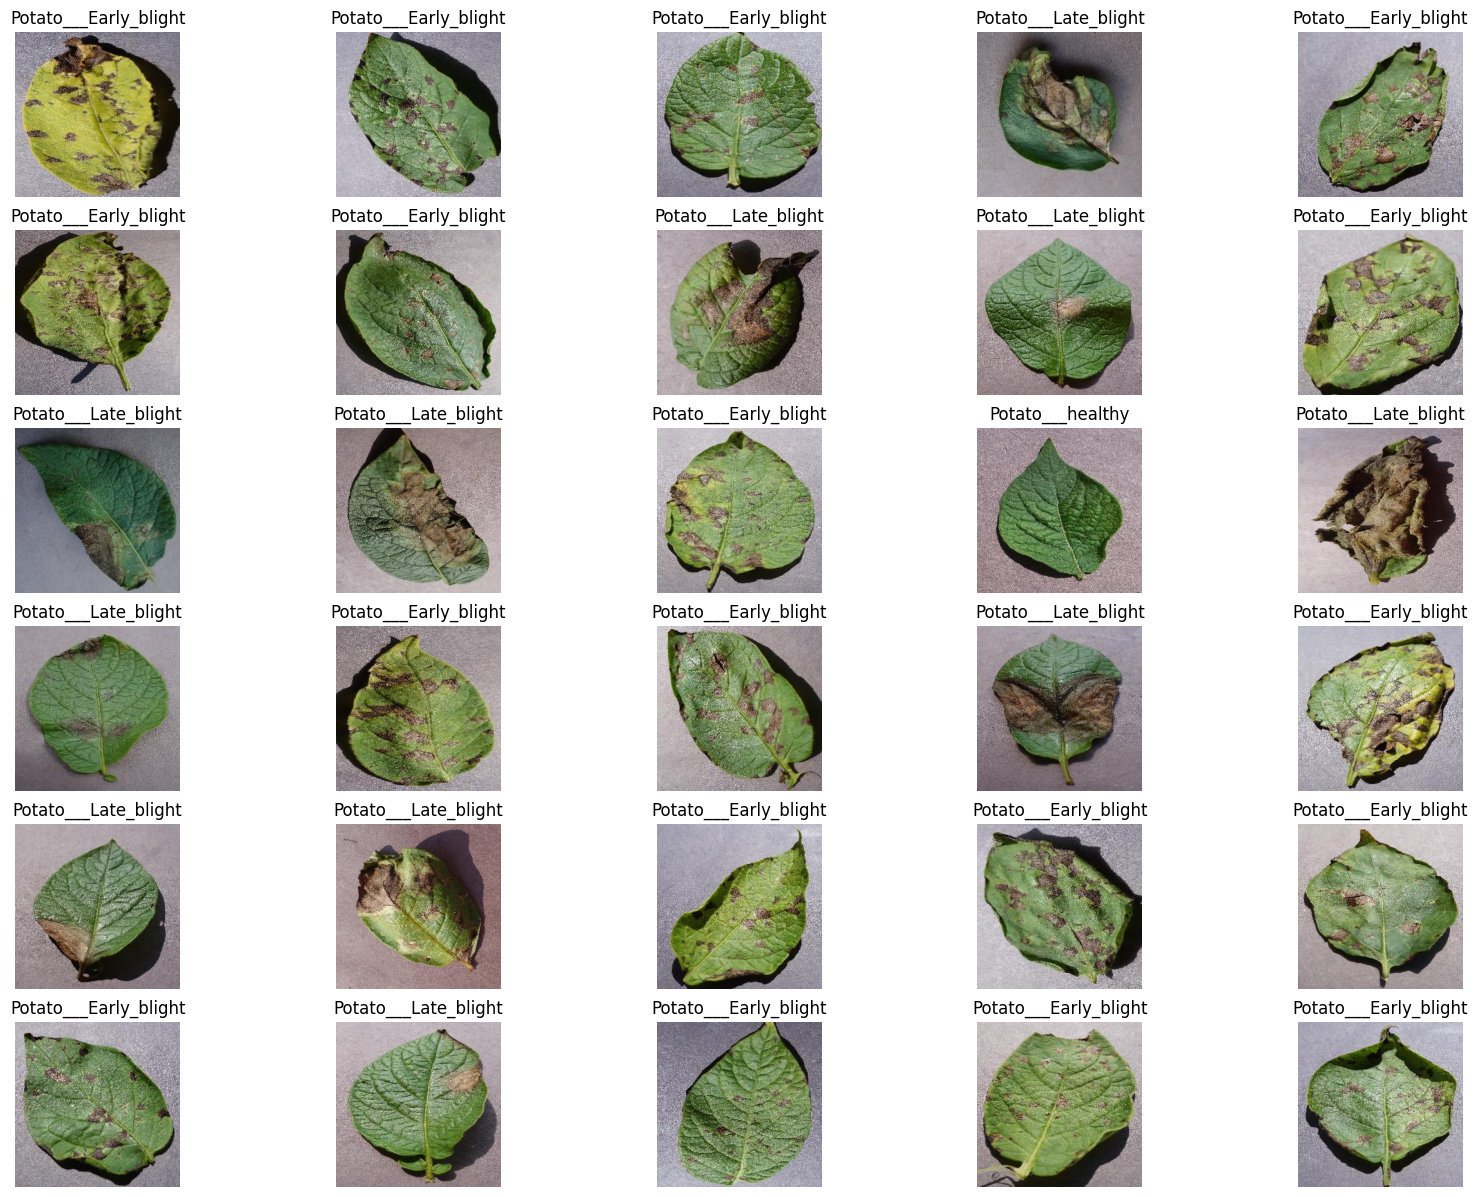

In [ ]:

# Define the path to the dataset and the class folders
dataset_dir = os.path.join(download_path, 'PlantVillage')
classes = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

# Collect image paths from all folders
all_image_paths = []
for class_dir in classes:
    class_path = os.path.join(dataset_dir, class_dir)
    image_files = os.listdir(class_path)
    for image_file in image_files:
        all_image_paths.append(os.path.join(class_path, image_file))

# Randomly select 30 image paths
random_image_paths = random.sample(all_image_paths, 30)

# Plot the images
plt.figure(figsize=(20, 15))
for i, img_path in enumerate(random_image_paths):
    img = Image.open(img_path)
    plt.subplot(6, 5, i + 1)  # 6 rows and 5 columns
    plt.imshow(img)
    class_name = os.path.basename(os.path.dirname(img_path))
    plt.title(class_name)
    plt.axis('off')
plt.show()

In [ ]:
# Define the paths
base_dir = os.path.join(download_path, 'PlantVillage')
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

# Initialize ImageDataGenerator for training and validation sets
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2,  # Split 20% for validation
    horizontal_flip=True,
    zoom_range=0.3,
    shear_range=0.3,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2
)

In [ ]:
# Load the training set
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(300, 300),  # Adjusted target size for EfficientNetB3
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

# Load the validation set
validation_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(300, 300),  # Adjusted target size for EfficientNetB3
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.


In [ ]:
# Get class indices from the training generator
class_indices = train_generator.class_indices
class_labels = list(class_indices.keys())

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

# Load the EfficientNetB3 model pre-trained on ImageNet
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))

# Add custom layers on top of EfficientNetB3
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax')(x)  # Assuming 3 classes: Early_blight, Late_blight, healthy

# Define the complete model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze all layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Set up early stopping, model checkpoint, and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, save_weights_only=False)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=15, min_lr=1e-6)
# Train the model with class weights and early stopping
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=50,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

Class weights: {0: np.float64(0.7175), 1: np.float64(0.7175), 2: np.float64(4.704918032786885)}
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 657s 6s/step - accuracy: 0.6544 - loss: 0.8449 - val_accuracy: 0.8582 - val_loss: 0.4132 - learning_rate: 1.0000e-04
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 1.0000 - loss: 0.1942 - val_accuracy: 0.8654 - val_loss: 0.4099 - learning_rate: 1.0000e-04
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 618s 6s/step - accuracy: 0.8946 - loss: 0.2771 - val_accuracy: 0.9038 - val_loss: 0.2448 - learning_rate: 1.0000e-04
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8125 - loss: 0.7720 - val_accuracy: 0.9014 - val_loss: 0.2563 - learning_rate: 1.0000e-04
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 662s 6s/step - accuracy: 0.9139 - loss: 0.2178 - val_accuracy: 0.8894 - val_loss: 0.2494 - learning_rate: 1.0000e-04
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8

In [ ]:
from tensorflow.keras.models import load_model

# Load the best model that was saved during your interrupted training
best_model = load_model('best_model.keras')

In [ ]:
# --- Step 2: Load the Best Model and Evaluate on Validation Set ---

# Load the best performing model saved by ModelCheckpoint
print("Loading the best model from 'best_model.keras'...")
best_model = load_model('best_model.keras')

# Evaluate the model on the validation data
print("\nEvaluating model performance on the validation set...")
evaluation_results = best_model.evaluate(validation_generator)

print(f"\n✅ Validation Loss: {evaluation_results[0]:.4f}")
print(f"✅ Validation Accuracy: {evaluation_results[1] * 100:.2f}%")

Loading the best model from 'best_model.keras'...

Evaluating model performance on the validation set...
27/27 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - accuracy: 0.9640 - loss: 0.1261

✅ Validation Loss: 0.1451
✅ Validation Accuracy: 95.35%


27/27 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step


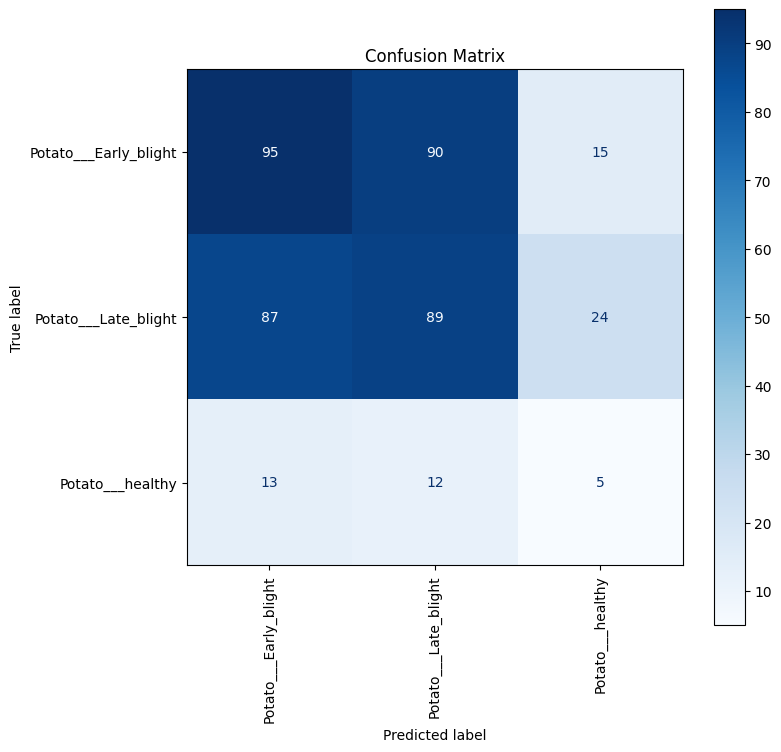

In [ ]:
# --- Step 3: Generate and Display a Confusion Matrix ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get the true labels from the validation generator
true_labels = validation_generator.classes

# Get the predicted labels for the entire validation set
# The 'steps' argument is important to ensure we cover all samples
predictions = best_model.predict(validation_generator, steps=len(validation_generator))
predicted_labels = np.argmax(predictions, axis=1)

# Get class names from the generator
class_names = list(validation_generator.class_indices.keys())

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


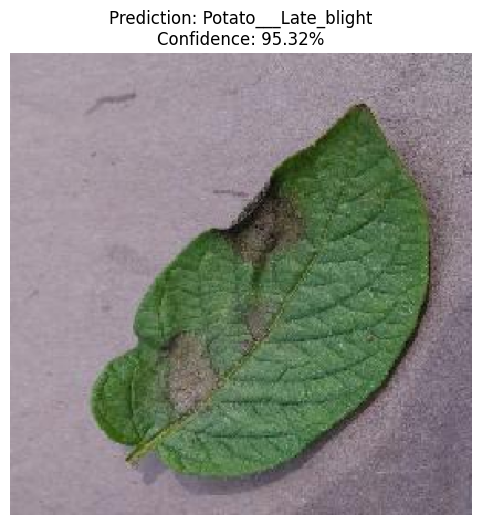

Image Path: /root/.cache/kagglehub/datasets/aarishasifkhan/plantvillage-potato-disease-dataset/versions/1/PlantVillage/Potato___Late_blight/2c33381e-78d8-47fc-8cea-1459164f46d6___RS_LB 4115.JPG
Predicted Class: Potato___Late_blight
Confidence Score: 95.32%


In [ ]:
# --- Step 4: Create a Function to Predict on a New Image ---

# Invert the class_indices dictionary to map index to label name
class_map = {v: k for k, v in train_generator.class_indices.items()}

def predict_image(image_path, model):
    """
    Loads an image, preprocesses it, and returns the model's prediction.
    """
    # 1. Load the image
    img = load_img(image_path, target_size=(300, 300))

    # 2. Convert to array and expand dimensions to create a batch of 1
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # 3. Preprocess the image (the same way as for training)
    preprocessed_img = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # 4. Make a prediction
    prediction = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(prediction, axis=1)[0]

    # 5. Get the class label and confidence score
    predicted_class_label = class_map[predicted_class_index]
    confidence_score = np.max(prediction) * 100

    return predicted_class_label, confidence_score, img

# --- Example Usage ---
# Let's test it on a random image from our validation set

# Get a random image path from the validation set
random_image_path = random.choice(validation_generator.filepaths)

# Make the prediction
predicted_label, confidence, original_image = predict_image(random_image_path, best_model)

# Display the results
plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
plt.axis('off')
plt.show()

print(f"Image Path: {random_image_path}")
print(f"Predicted Class: {predicted_label}")
print(f"Confidence Score: {confidence:.2f}%")